In [34]:
import pandas as pd
import allel
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
import pickle
with open('../key_files/blocks_snpsid_dict.pkl', 'rb') as f:
    dict_blocks = pickle.load(f)

reverse_mapping = {item: key for key, values in dict_blocks.items() for item in values}

#snps_names = snps_names[snps_names['total_alleles05filter_firstgen'].notna()].reset_index(drop=True)

In [164]:
clim1001 = pd.read_csv('../key_files/1001g_regmap_grenet_ecotype_info_corrected_bioclim_2024May16.csv')

clim1001['ecotypeid'] = clim1001['ecotypeid'].astype(str)


In [165]:
vcfgrene = allel.read_vcf('../key_files/greneNet_final_v1.1_LDpruned.recode.vcf')

In [166]:
#vcfgrene = allel.read_vcf('../gwas/1001g/1001g_grenet_climate.recode.vcf')
geno = vcfgrene['calldata/GT']

geno = geno.sum(axis=2)

geno = pd.DataFrame(geno)

geno.columns = vcfgrene['samples']

grene_chrom_pos = pd.DataFrame({'chrom': vcfgrene['variants/CHROM'], 'pos': vcfgrene['variants/POS']})

#vcfgrene = pd.concat([grene_chrom_pos, geno],axis=1)

In [167]:
clim1001 = clim1001[clim1001['ecotypeid'].isin(geno.columns)]

In [168]:
clim1001 = clim1001[['ecotypeid', 'bio1']]

In [169]:
clim1001['ecotypeid'] = clim1001['ecotypeid'].astype(str)

In [170]:
clim1001_dict = clim1001.set_index('ecotypeid')['bio1'].to_dict()

In [171]:
len(clim1001_dict)

231

In [172]:
geno.columns

Index(['10002', '10006', '10011', '10013', '10014', '159', '265', '5151',
       '5165', '5768',
       ...
       '9965', '9966', '9978', '9985', '100001', '100002', '6939', '9940',
       '9977', '9992'],
      dtype='object', length=231)

In [173]:
clim1001 = clim1001.set_index('ecotypeid')

In [174]:
geno = geno.T

In [175]:
geno = geno.sort_index()

In [176]:
order_ecotypes = geno.index

In [177]:
clim1001 = clim1001.sort_index()

In [178]:
geno = geno.reset_index(drop=True)

In [179]:
clim1001 = clim1001.reset_index(drop=True)

In [180]:
#unique, counts = np.unique(geno, return_counts=True)  # array([666040577,     40258,  81315045])

In [181]:
#geno = np.where(geno == 0, -1, geno)  # Replace 0 with -1
#geno = np.where(geno == 2, 1, geno)  # Replace 2 with 1
#geno = np.where(geno == 1, 0, geno)  # Replace 1

In [182]:
clim1001

,bio1
0,15.829166
1,15.100000
2,8.879167
3,11.320833
4,7.704167
...,...
226,13.812500
227,8.716667
228,8.716667
229,8.387500


<Axes: xlabel='bio1', ylabel='Count'>

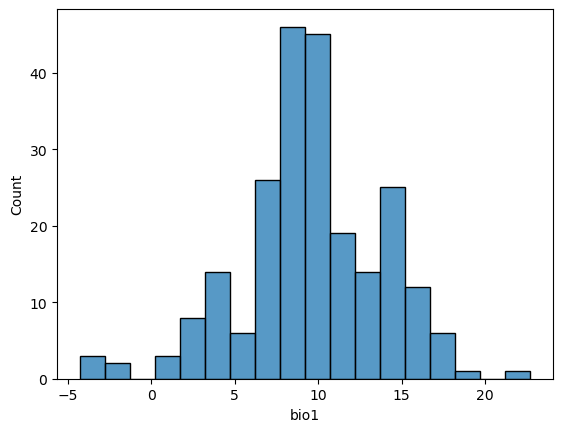

In [183]:
sns.histplot(clim1001['bio1'])

9.584559885454384

In [186]:
clim1001 = np.array(clim1001)

temperature_centered = clim1001 - np.mean(clim1001)

snp_temperature_association = np.array(geno).T.dot(np.array(temperature_centered))

snp_temperature_association /= len(clim1001)

snp_temperature_association = pd.Series(snp_temperature_association.flatten())

<Axes: ylabel='Count'>

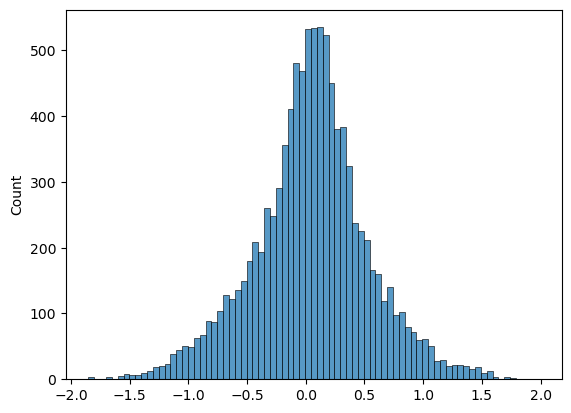

In [187]:
sns.histplot(pd.Series(snp_temperature_association).sample(10000))

In [188]:
snp_origin_bio1 = pd.DataFrame({'chrom': vcfgrene['variants/CHROM'], 'pos': vcfgrene['variants/POS'], 'snp_origin_bio1': snp_temperature_association})

In [189]:
snp_origin_bio1

,chrom,pos,snp_origin_bio1
0,1,6771,-0.314456
1,1,13538,0.685395
2,1,20088,0.060205
3,1,24738,-0.445239
4,1,33651,0.380421
...,...,...,...
13980,5,26922448,-1.297697
13981,5,26964964,-0.326091
13982,5,26965354,0.234621
13983,5,26973977,-0.091119


In [190]:
#snp_origin_bio1 = pd.read_csv('../key_files/snp_origin_bio1_grenenetvcf.csv')

dict_snps = pd.read_csv('../key_files/var_pos_grenenet.csv')

#snp_origin_bio1 = pd.concat([dict_snps['id'], snp_origin_bio1],axis=1)

In [191]:
dict_snps['pos'] = dict_snps['pos'].astype(int)
dict_snps['chrom'] = dict_snps['chrom'].astype(str)

In [192]:
snp_origin_bio1 = snp_origin_bio1.merge(dict_snps[['pos', 'chrom','id']], on = ['pos', 'chrom'])

In [193]:
af_ld = pd.read_csv('../key_files/merged_hapFIRE_allele_frequency_LDpruned.txt', sep ='\t')

In [194]:
vcf = allel.read_vcf('../key_files/greneNet_final_v1.1_LDpruned.recode.vcf')

In [195]:
snps_id = vcf['variants/ID']

In [196]:
af_ld.index = snps_id

In [197]:
final_gen = pd.read_csv('../key_files/final_gen.csv')['sample_name'].to_list()

In [198]:
af_ld_final_gen = af_ld[final_gen]

In [199]:
climate = pd.read_csv('../key_files/bioclimvars_experimental_sites_era5.csv')[['site', 'bio1']]

In [200]:
#climate['distance_to_mean'] = climate['bio1'] - climate['bio1'].mean()

In [201]:
climate['site'] = climate['site'].astype(str)

In [202]:
cl_firstyear = pd.Series(final_gen).str.split('_').str[0].reset_index().merge(climate[['site', 'bio1']], left_on = 0,right_on = 'site', how = 'left')

In [203]:
cl_firstyear['samples'] = final_gen

<Axes: xlabel='bio1', ylabel='Count'>

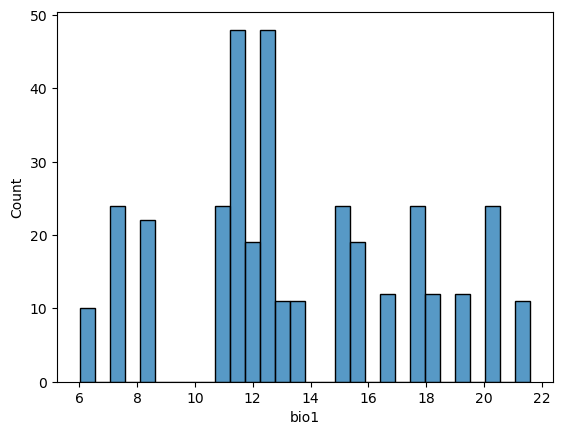

In [224]:
sns.histplot(cl_firstyear['bio1'],bins = 30)

In [204]:
dict_samples_cl  = cl_firstyear.set_index('samples')['bio1'].to_dict()

In [205]:
af_ld_final_gen.columns = af_ld_final_gen.columns.map(dict_samples_cl)

In [206]:
af_ld_final_gen = af_ld_final_gen.T.reset_index()

In [207]:
af_ld_final_gen = af_ld_final_gen.groupby('index')[af_ld_final_gen.columns[1:]].mean().T

In [208]:
af_ld_final_gen = af_ld_final_gen.reset_index()

In [209]:
af_ld_final_gen

index,index,6.00886075833333,7.290877075,7.42514504583333,8.130012135,8.50676815416667,10.7439056875,10.927050325,11.2770271166667,11.3935151425,...,15.59462670375,15.65428636375,16.8683085291667,17.5134744333333,17.8151688958333,18.0009508,19.2480514166667,20.4127104883333,20.5509234475,21.6033558083333
0,1_6771,0.061358,0.096357,0.055529,0.077415,0.070461,0.028178,0.064842,0.044589,0.035456,...,0.029340,0.044250,0.034153,0.063304,0.104381,0.052784,0.039217,0.058875,0.039431,0.106296
1,1_13538,0.381885,0.449333,0.697364,0.419993,0.305277,0.474169,0.613690,0.483398,0.460255,...,0.587360,0.674694,0.392832,0.707349,0.702892,0.671966,0.621782,0.473632,0.501125,0.538799
2,1_20088,0.082076,0.068927,0.027187,0.089711,0.034513,0.072428,0.044940,0.082253,0.062658,...,0.187344,0.031868,0.052734,0.101429,0.101484,0.059592,0.110183,0.102289,0.123691,0.174011
3,1_24738,0.485990,0.525381,0.794273,0.453462,0.342107,0.635747,0.563406,0.539841,0.542564,...,0.628025,0.465907,0.479907,0.363993,0.768770,0.520369,0.587548,0.626597,0.542902,0.541143
4,1_33651,0.461199,0.516418,0.287187,0.459936,0.497979,0.456103,0.546246,0.442339,0.414624,...,0.392326,0.598620,0.443029,0.803604,0.508254,0.662087,0.394833,0.438550,0.406435,0.528791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13980,5_26922448,0.386104,0.493033,0.794527,0.441024,0.622726,0.310425,0.287707,0.362682,0.477588,...,0.408801,0.175229,0.286889,0.168817,0.460971,0.212454,0.441720,0.276555,0.337378,0.351997
13981,5_26964964,0.074228,0.146024,0.048883,0.081816,0.165710,0.111207,0.062801,0.068886,0.039187,...,0.057280,0.056064,0.041642,0.066811,0.054467,0.051538,0.038632,0.058225,0.067263,0.131763
13982,5_26965354,0.202546,0.075373,0.042433,0.051911,0.060260,0.128817,0.075986,0.089642,0.035585,...,0.158514,0.084624,0.057588,0.063557,0.137672,0.062378,0.076202,0.023210,0.051987,0.042316
13983,5_26973977,0.066093,0.054866,0.039309,0.091712,0.053106,0.037983,0.066738,0.091660,0.065220,...,0.044285,0.067813,0.159472,0.037506,0.038754,0.018941,0.066205,0.127545,0.174235,0.037499


In [210]:
snp_origin_bio1

,chrom,pos,snp_origin_bio1,id
0,1,6771,-0.314456,1_6771
1,1,13538,0.685395,1_13538
2,1,20088,0.060205,1_20088
3,1,24738,-0.445239,1_24738
4,1,33651,0.380421,1_33651
...,...,...,...,...
13980,5,26922448,-1.297697,5_26922448
13981,5,26964964,-0.326091,5_26964964
13982,5,26965354,0.234621,5_26965354
13983,5,26973977,-0.091119,5_26973977


In [211]:
snp_origin_bio1 = snp_origin_bio1[snp_origin_bio1['id'].isin(af_ld.index)].reset_index(drop=True)

In [212]:
snp_origin_bio1

,chrom,pos,snp_origin_bio1,id
0,1,6771,-0.314456,1_6771
1,1,13538,0.685395,1_13538
2,1,20088,0.060205,1_20088
3,1,24738,-0.445239,1_24738
4,1,33651,0.380421,1_33651
...,...,...,...,...
13980,5,26922448,-1.297697,5_26922448
13981,5,26964964,-0.326091,5_26964964
13982,5,26965354,0.234621,5_26965354
13983,5,26973977,-0.091119,5_26973977


In [213]:
af_ld_final_gen

index,index,6.00886075833333,7.290877075,7.42514504583333,8.130012135,8.50676815416667,10.7439056875,10.927050325,11.2770271166667,11.3935151425,...,15.59462670375,15.65428636375,16.8683085291667,17.5134744333333,17.8151688958333,18.0009508,19.2480514166667,20.4127104883333,20.5509234475,21.6033558083333
0,1_6771,0.061358,0.096357,0.055529,0.077415,0.070461,0.028178,0.064842,0.044589,0.035456,...,0.029340,0.044250,0.034153,0.063304,0.104381,0.052784,0.039217,0.058875,0.039431,0.106296
1,1_13538,0.381885,0.449333,0.697364,0.419993,0.305277,0.474169,0.613690,0.483398,0.460255,...,0.587360,0.674694,0.392832,0.707349,0.702892,0.671966,0.621782,0.473632,0.501125,0.538799
2,1_20088,0.082076,0.068927,0.027187,0.089711,0.034513,0.072428,0.044940,0.082253,0.062658,...,0.187344,0.031868,0.052734,0.101429,0.101484,0.059592,0.110183,0.102289,0.123691,0.174011
3,1_24738,0.485990,0.525381,0.794273,0.453462,0.342107,0.635747,0.563406,0.539841,0.542564,...,0.628025,0.465907,0.479907,0.363993,0.768770,0.520369,0.587548,0.626597,0.542902,0.541143
4,1_33651,0.461199,0.516418,0.287187,0.459936,0.497979,0.456103,0.546246,0.442339,0.414624,...,0.392326,0.598620,0.443029,0.803604,0.508254,0.662087,0.394833,0.438550,0.406435,0.528791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13980,5_26922448,0.386104,0.493033,0.794527,0.441024,0.622726,0.310425,0.287707,0.362682,0.477588,...,0.408801,0.175229,0.286889,0.168817,0.460971,0.212454,0.441720,0.276555,0.337378,0.351997
13981,5_26964964,0.074228,0.146024,0.048883,0.081816,0.165710,0.111207,0.062801,0.068886,0.039187,...,0.057280,0.056064,0.041642,0.066811,0.054467,0.051538,0.038632,0.058225,0.067263,0.131763
13982,5_26965354,0.202546,0.075373,0.042433,0.051911,0.060260,0.128817,0.075986,0.089642,0.035585,...,0.158514,0.084624,0.057588,0.063557,0.137672,0.062378,0.076202,0.023210,0.051987,0.042316
13983,5_26973977,0.066093,0.054866,0.039309,0.091712,0.053106,0.037983,0.066738,0.091660,0.065220,...,0.044285,0.067813,0.159472,0.037506,0.038754,0.018941,0.066205,0.127545,0.174235,0.037499


In [214]:
final = snp_origin_bio1.merge(af_ld_final_gen, left_on = 'id', right_on = 'index')

In [215]:
final.columns

Index([          'chrom',             'pos', 'snp_origin_bio1',
                    'id',           'index',  6.00886075833333,
             7.290877075,  7.42514504583333,       8.130012135,
        8.50676815416667,     10.7439056875,      10.927050325,
        11.2770271166667,     11.3935151425,  11.5645014791667,
        11.7212804541667,        12.0052842,  12.1987028595833,
          12.27648105125,     12.3622173525,     12.4401688625,
        12.4816687833333,  12.9571620166667,     13.8013959575,
        14.9890791533333,    14.99635534775,    15.59462670375,
          15.65428636375,  16.8683085291667,  17.5134744333333,
        17.8151688958333,        18.0009508,  19.2480514166667,
        20.4127104883333,     20.5509234475,  21.6033558083333],
      dtype='object')

In [216]:
final = final[[ 'snp_origin_bio1',      6.00886075833333,
             7.290877075,  7.42514504583333,       8.130012135,
        8.50676815416667,     10.7439056875,      10.927050325,
        11.2770271166667,     11.3935151425,  11.5645014791667,
        11.7212804541667,        12.0052842,  12.1987028595833,
          12.27648105125,     12.3622173525,     12.4401688625,
        12.4816687833333,  12.9571620166667,     13.8013959575,
        14.9890791533333,    14.99635534775,    15.59462670375,
          15.65428636375,  16.8683085291667,  17.5134744333333,
        17.8151688958333,        18.0009508,  19.2480514166667,
        20.4127104883333,     20.5509234475,  21.6033558083333]].melt(id_vars = 'snp_origin_bio1')

In [229]:
final['variable'] = final['variable'] - np.mean(clim1001)

In [234]:
final['cd'] = final['snp_origin_bio1'] * final['variable']

In [235]:
final

,snp_origin_bio1,variable,value,cd
0,-0.314456,-3.575699,0.061358,1.124399
1,0.685395,-3.575699,0.381885,-2.450766
2,0.060205,-3.575699,0.082076,-0.215274
3,-0.445239,-3.575699,0.485990,1.592041
4,0.380421,-3.575699,0.461199,-1.36027
...,...,...,...,...
433530,-1.297697,12.018796,0.351997,-15.59675
433531,-0.326091,12.018796,0.131763,-3.919221
433532,0.234621,12.018796,0.042316,2.819865
433533,-0.091119,12.018796,0.037499,-1.095144


<Axes: xlabel='variable', ylabel='Count'>

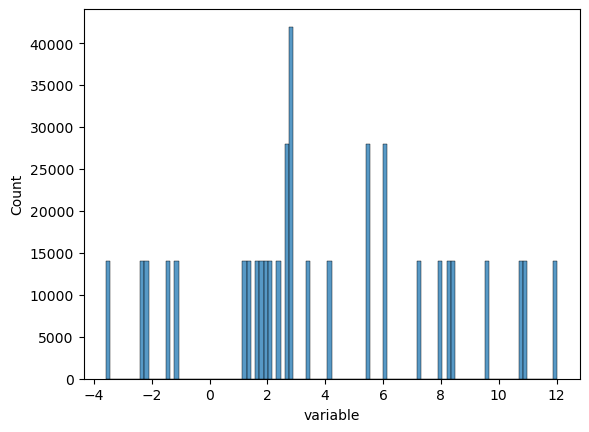

In [236]:
sns.histplot(final['variable'] )

<Axes: xlabel='cd', ylabel='value'>

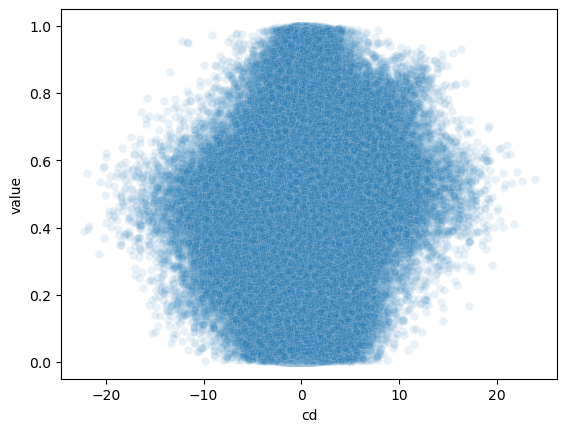

In [237]:
sns.scatterplot(data = final, x = 'cd', y = 'value', alpha = 0.1)

In [238]:
final

,snp_origin_bio1,variable,value,cd
0,-0.314456,-3.575699,0.061358,1.124399
1,0.685395,-3.575699,0.381885,-2.450766
2,0.060205,-3.575699,0.082076,-0.215274
3,-0.445239,-3.575699,0.485990,1.592041
4,0.380421,-3.575699,0.461199,-1.36027
...,...,...,...,...
433530,-1.297697,12.018796,0.351997,-15.59675
433531,-0.326091,12.018796,0.131763,-3.919221
433532,0.234621,12.018796,0.042316,2.819865
433533,-0.091119,12.018796,0.037499,-1.095144


In [239]:
final_pivot = final.pivot_table(index='snp_origin_bio1', columns= 'variable', values = 'value')

In [240]:
final_pivot

variable,-3.575699,-2.293683,-2.159415,-1.454548,-1.077792,1.159346,1.342490,1.692467,1.808955,1.979942,...,6.010067,6.069726,7.283749,7.928915,8.230609,8.416391,9.663492,10.828151,10.966364,12.018796
snp_origin_bio1,,,,,,,,,,,,,,,,,,,,,
-1.850737,0.662551,0.607994,0.604931,0.674020,0.574217,0.554279,0.372115,0.597210,0.605555,0.286346,...,0.416486,0.171627,0.507320,0.106801,0.087215,0.169279,0.383945,0.497869,0.576757,0.389278
-1.821759,0.514774,0.578658,0.583454,0.540973,0.580973,0.383907,0.300885,0.496077,0.625026,0.282352,...,0.398625,0.220951,0.350398,0.217231,0.089596,0.246111,0.377469,0.449775,0.621410,0.562117
-1.819702,0.488767,0.529582,0.926882,0.543809,0.526008,0.519735,0.415648,0.483138,0.456213,0.182522,...,0.400351,0.312391,0.550830,0.136673,0.138235,0.183927,0.389119,0.438272,0.609604,0.396345
-1.806019,0.613920,0.573813,0.623685,0.582210,0.592516,0.367606,0.320671,0.446201,0.518317,0.167355,...,0.466013,0.246868,0.382801,0.210206,0.162687,0.241230,0.434998,0.552481,0.530214,0.405721
-1.725377,0.344831,0.470637,0.600128,0.504523,0.473601,0.238176,0.313250,0.393580,0.421906,0.248847,...,0.358971,0.315235,0.277219,0.151706,0.185184,0.233920,0.357271,0.377413,0.502581,0.322521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.752531,0.424440,0.446848,0.444477,0.464143,0.470175,0.519708,0.757847,0.488360,0.449549,0.831413,...,0.594250,0.834521,0.592838,0.889684,0.917312,0.826666,0.605407,0.525904,0.483965,0.644198
1.779587,0.493769,0.413822,0.169763,0.403290,0.438379,0.606478,0.683065,0.458543,0.446173,0.756929,...,0.606816,0.787719,0.600021,0.873894,0.608339,0.781847,0.625137,0.568673,0.288964,0.619760
1.834132,0.392143,0.402112,0.286631,0.383111,0.322234,0.564491,0.615147,0.598939,0.477807,0.722167,...,0.440463,0.652296,0.524619,0.822213,0.764751,0.718397,0.507824,0.545548,0.458067,0.565924


<Axes: xlabel='variable', ylabel='snp_origin_bio1'>

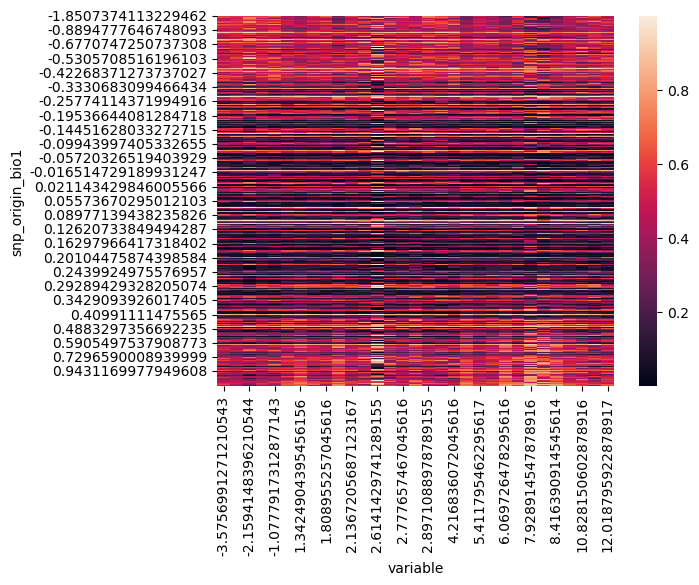

In [241]:
sns.heatmap(final_pivot)

In [249]:
from scipy.ndimage import gaussian_filter

# Convert DataFrame to a NumPy array for processing
data_matrix = final_pivot.T.to_numpy()

# Replace NaN values with 0, so they don't affect the smoothing
data_matrix[np.isnan(data_matrix)] = 0

# Apply Gaussian smoothing
smoothed_matrix = gaussian_filter(data_matrix, sigma=20)

# Optionally, set zeros back to NaN for ignoring them in the plot
smoothed_matrix[smoothed_matrix == 0] = np.nan

<Axes: >

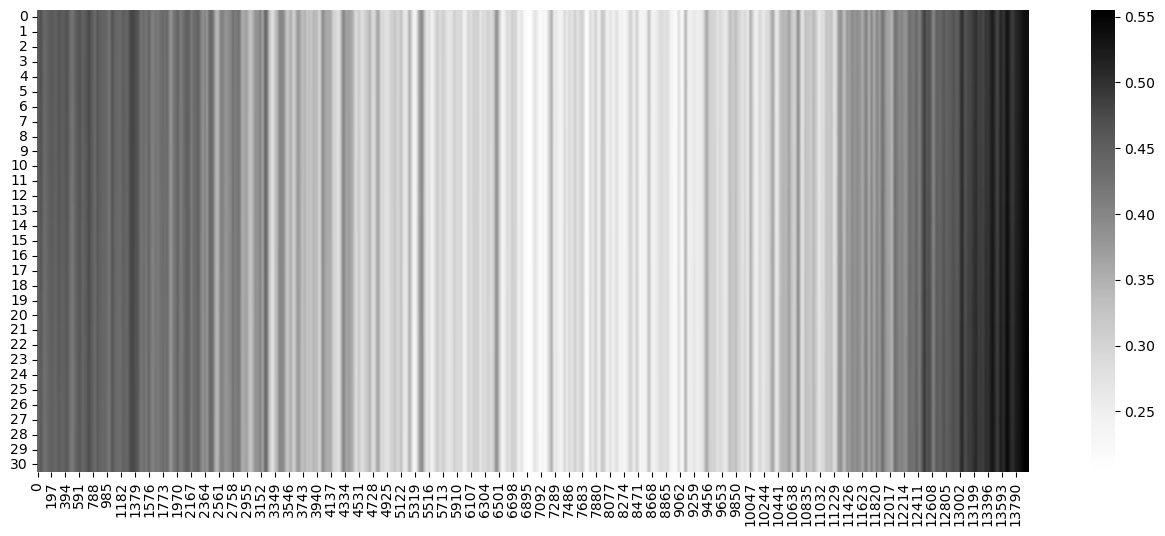

In [250]:
plt.figure(figsize=(16, 6))  # Set the size of the figure
sns.heatmap(pd.DataFrame(smoothed_matrix), cmap='Greys')